#Experiment 9. Implement an autoregressive model, such as Pixel CNN or Pixel RNN, using a deep learning framework


Epoch 5/20  Loss: 1.4404
Epoch 10/20  Loss: 1.1723
Epoch 15/20  Loss: 0.8269
Epoch 20/20  Loss: 0.5015

Generated Sequence: [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]


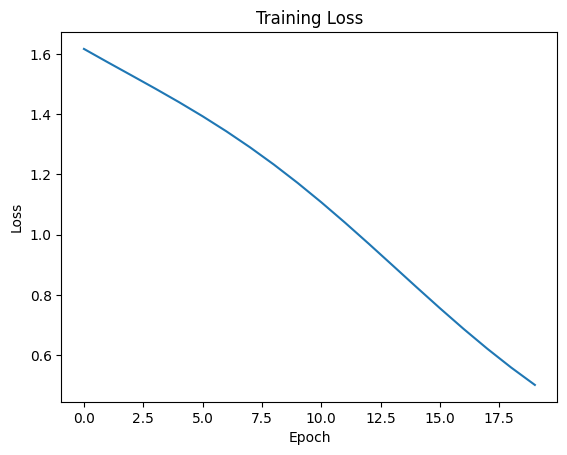

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Step 1: Simple Pattern Dataset
# Pattern: 0 → 1 → 2 → 3 → 4 → repeat
seq_len = 10
vocab_size = 5
samples = 1000

data = []
for _ in range(samples):
    start = torch.randint(0, vocab_size, (1,))
    seq = [(start.item() + i) % vocab_size for i in range(seq_len)]
    data.append(seq)

data = torch.tensor(data)

x = data[:, :-1]  # input
y = data[:, 1:]   # target (next token)

# Step 2: Model
class SimpleLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 16)
        self.lstm = nn.LSTM(16, 32, batch_first=True)
        self.fc = nn.Linear(32, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.lstm(x)
        return self.fc(out)

model = SimpleLSTM()

#  Step 3: Training Setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()

losses = []

#  Step 4: Training
for epoch in range(20):
    pred = model(x)
    loss = loss_fn(pred.reshape(-1, vocab_size), y.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/20  Loss: {loss.item():.4f}")

# Step 5: Generate Sequence
model.eval()
with torch.no_grad():
    start = torch.tensor([[0]])  # starting token
    generated = [0]
    inp = start
    h = None

    for _ in range(seq_len - 1):
        out, h = model.lstm(model.embed(inp), h)
        logits = model.fc(out[:, -1, :])
        next_token = torch.argmax(logits, dim=1)

        generated.append(next_token.item())
        inp = next_token.unsqueeze(0)

print("\nGenerated Sequence:", generated)

# Step 6: Plot Loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()